dodac koment....


In [1]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score,f1_score
import seaborn as sns
from utils import feature_in, feature_in_LR, feature_in_SVC, feature_in_XGB, make_preprocessor

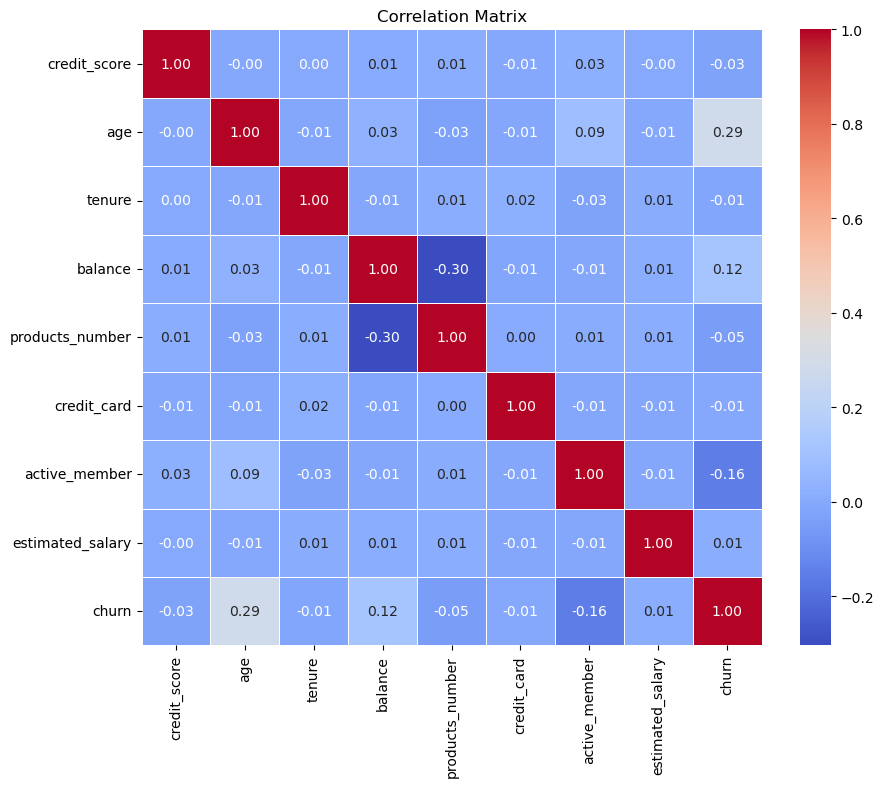

In [2]:
# correlation analiz
df_org_data = pd.read_csv('Data/Bank Customer Churn Prediction.csv')
df_org_data = df_org_data.drop('customer_id', axis=1)
num_df_org_data = df_org_data.select_dtypes(include=['int64', 'float64'])
cat_df_org_dat = df_org_data.select_dtypes(include=['object', 'string'])
corr = num_df_org_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

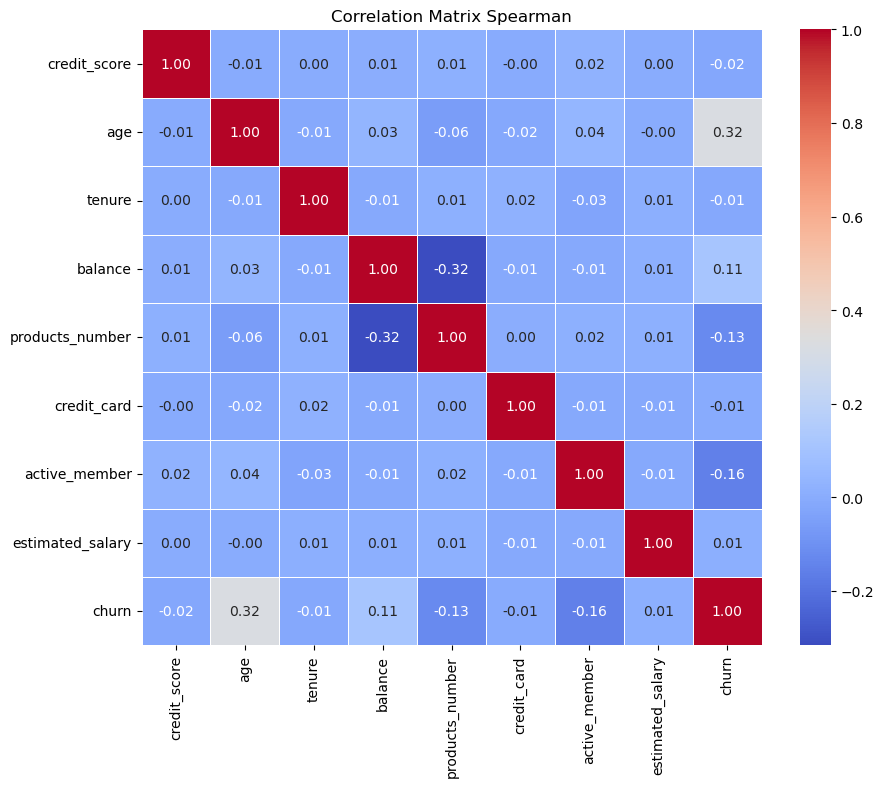

In [3]:
corr = num_df_org_data.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix Spearman')
plt.show()

In [4]:
# Outliers detection
# for col in num_df_org_data.columns:
#     plt.figure(figsize=(10,6))
#     sns.boxplot(data=num_df_org_data[col])
#     plt.title("Boxplot - Outliers detection")
#     plt.show()

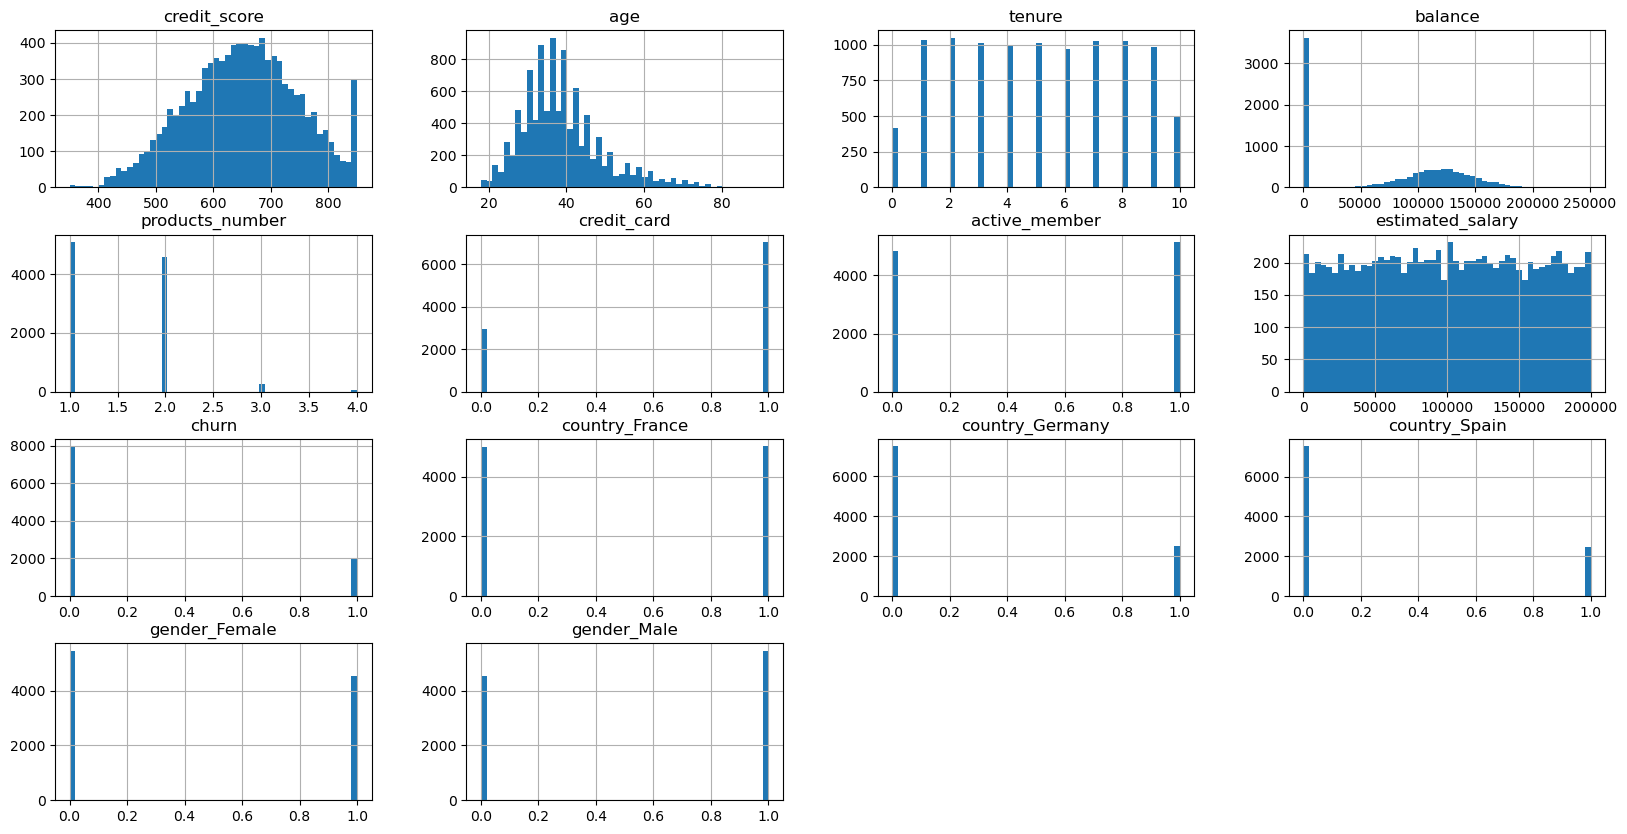

In [5]:
# manual data visualization (base data)
o_h_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_cols_d = cat_df_org_dat.columns
D_cat = o_h_encoder.fit_transform(df_org_data[cat_cols_d])
features_names_data = o_h_encoder.get_feature_names_out(cat_cols_d)
df_D_cat = pd.DataFrame(D_cat, columns=features_names_data, index=df_org_data.index)
df_org_data_in = pd.concat([df_org_data, df_D_cat], axis=1)
df_org_data_in.hist(bins=50, figsize=(20, 10))
plt.show()

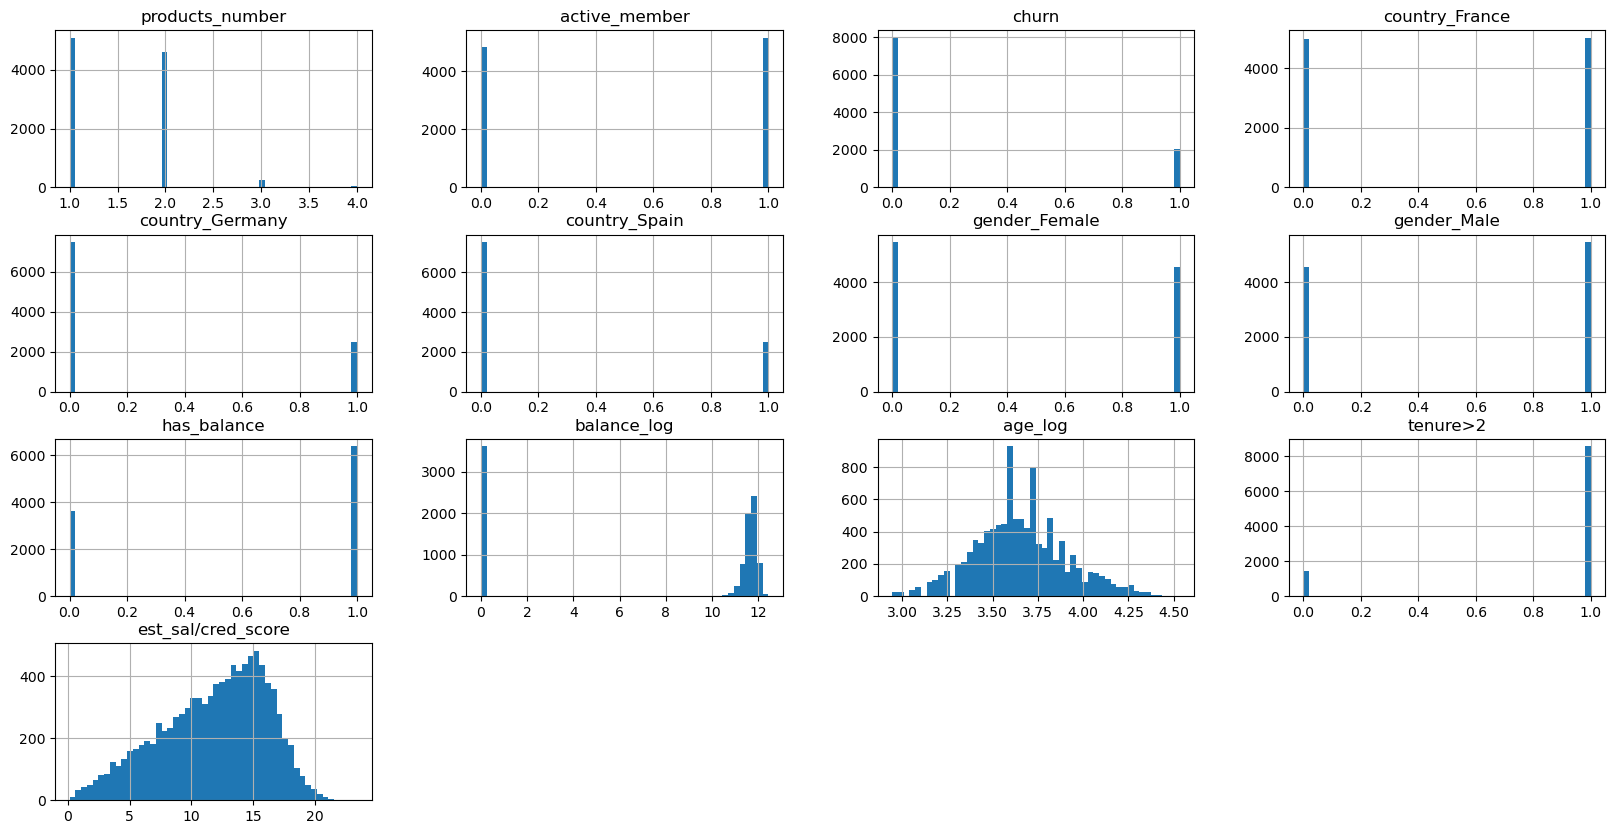

In [6]:
# histograms for models : LR XGB SVC
# the data transformation functions are based on the analysis in files: XGB_fe.ipynb, LR_fe.ipynb, SVC_fe.ipynb
df_org_data_in_fe = feature_in(df_org_data_in, for_model='SVC')  # histograms for models : LR XGB SVC
df_org_data_in_fe.hist(bins=50, figsize=(20, 10))
plt.show()

In [7]:
df = pd.read_csv('Data/Bank Customer Churn Prediction.csv')
customer_ids = df['customer_id']
df = df.drop('customer_id', axis=1)

y = df['churn']
X = df.drop('churn', axis=1)

X_train_raw, X_test_raw, y_train, y_test, id_train, id_test = train_test_split(
    X, y,
    customer_ids,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# def make_preprocessor(X, scale_numeric=True):
#     num_cols = X.select_dtypes(include=['int64', 'float64']).columns
#     cat_cols = X.select_dtypes(include=['object', 'string']).columns
#     num_step = [('imputer', SimpleImputer(strategy='median'))]
#     if scale_numeric:
#         num_step.append(('scaler', StandardScaler()))
#     num_pipeline = Pipeline(num_step)
#
#     cat_pipeline = Pipeline([
#         ('imputer', SimpleImputer(strategy='most_frequent')),
#         ('onehot', OneHotEncoder(handle_unknown='ignore'))
#     ])
#
#     return ColumnTransformer([
#         ('num', num_pipeline, num_cols),
#         ('cat', cat_pipeline, cat_cols)
#     ])

In [9]:
#the hyperparameters are obtained using Optuna optimization from SVC_optuna.ipynb
model_SVC = Pipeline([
    ('features', FunctionTransformer(feature_in_SVC)),
    ('preprocessor', make_preprocessor(feature_in_SVC(X_train_raw), scale_numeric=True)),
    ('model', SVC(
        probability=True,
        random_state=42,
        kernel='rbf',
        C=0.308,
        class_weight='balanced',
        gamma='scale'
    ))
])

In [10]:
#the hyperparameters are obtained using Optuna optimization from LR_optuna.ipynb
model_LR = Pipeline([
    ('features', FunctionTransformer(feature_in_LR)),
    ('preprocessor', make_preprocessor(feature_in_LR(X_train_raw), scale_numeric=True)),
    ('model', LogisticRegression(
        solver='lbfgs',
        C=3.7,
        max_iter=2541,
        class_weight='balanced',
        random_state=42
    ))
])

In [11]:
#the hyperparameters are obtained using Optuna optimization from XGB_optuna.ipynb
model_XGB = Pipeline([
    ('features', FunctionTransformer(feature_in_XGB)),
    ('preprocessor', make_preprocessor(feature_in_XGB(X_train_raw), scale_numeric=False)),
    ('model', XGBClassifier(
        n_estimators=1067,
        max_depth=6,
        learning_rate=0.082,
        subsample=0.846,
        colsample_bytree=0.6275,
        gamma=4.58,
        min_child_weight=6,
        reg_alpha=4.832,
        reg_lambda=0.1434,
        scale_pos_weight=2.92,
        eval_metric='logloss'
    ))
])

In [12]:
voting_model = VotingClassifier(
    estimators=[
        ('svc', model_SVC),
        ('lr', model_LR),
        ('xgb', model_XGB)
    ],
    voting='soft',
    weights=[1, 1, 1],
    n_jobs=-1
)

In [28]:
# cross valu score precision, recall, roc_auc
for test in ["precision", "recall", "roc_auc"]:
    punkty_model_LR=cross_val_score(estimator=voting_model,X=X_train_raw,y=y_train, cv=5,scoring=test)
    print(test,": ", punkty_model_LR.mean().round(2))

precision :  0.59
recall :  0.65
roc_auc :  0.86


In [14]:
voting_model.fit(X_train_raw, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svc', ...), ('lr', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[1, 1, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...t 0x14f8282c0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True


In [15]:
y_pred = voting_model.predict(X_test_raw)
y_proba = voting_model.predict_proba(X_test_raw)[:, 1]

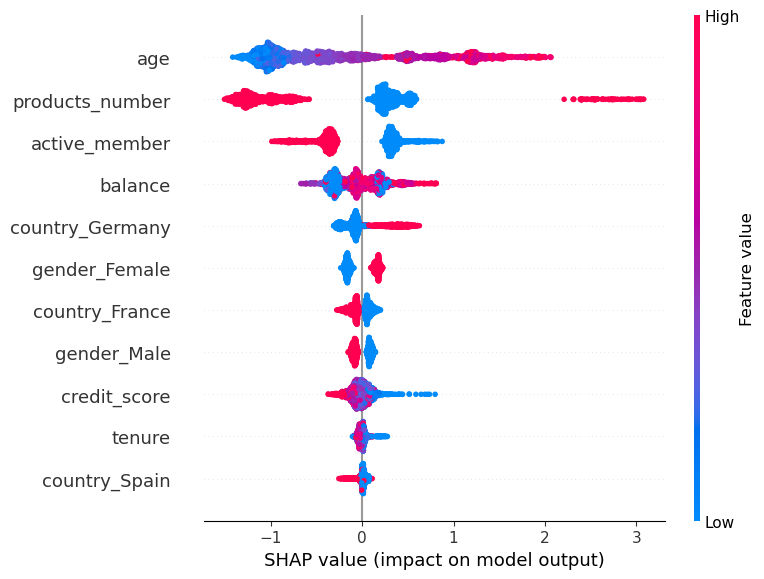

In [16]:
model_XGB.fit(X_train_raw, y_train)

preproc = model_XGB.named_steps['preprocessor']
XGB_model = model_XGB.named_steps['model']

X_train_feat = feature_in_XGB(X_train_raw)
X_test_feat = feature_in_XGB(X_test_raw)

X_train_t = preproc.transform(X_train_feat)
X_test_t = preproc.transform(X_test_feat)

feature_names = preproc.get_feature_names_out()
feature_names = [k.split('__')[1] for k in feature_names]
explainer = shap.TreeExplainer(XGB_model)

shap_values = explainer(X_test_t)

plt.figure()
shap.summary_plot(shap_values, X_test_t, feature_names=feature_names)
plt.show()

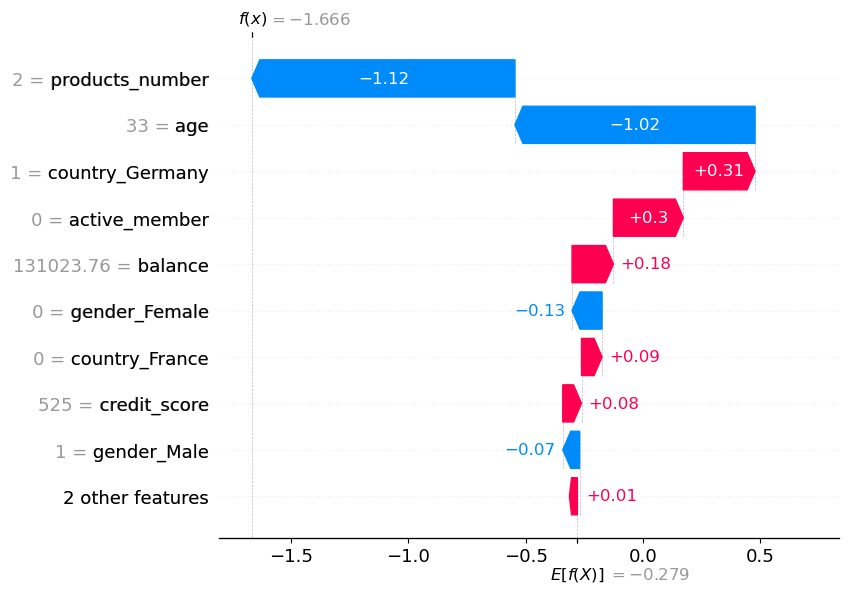

In [17]:

feature_names_waterf = preproc.get_feature_names_out()
X_test_t_df = pd.DataFrame(
    X_test_t,
    columns=[k.split('__')[1] for k in feature_names_waterf]
)
shap_values = explainer(X_test_t_df)
plt.figure()
shap.plots.waterfall(shap_values[1])
plt.show()

In [18]:
# shap data frame for final file
df_shap = pd.DataFrame(shap_values.values, columns=feature_names, index=X_test_raw.index)
df_shap.iloc[1]

credit_score       0.079841
age               -1.022906
tenure             0.014609
balance            0.176267
products_number   -1.120842
active_member      0.297739
country_France     0.087483
country_Germany    0.305622
country_Spain     -0.005204
gender_Female     -0.127840
gender_Male       -0.071647
Name: 3667, dtype: float32

In [19]:
conf_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(conf_matrix)


[[1419  174]
 [ 137  270]]


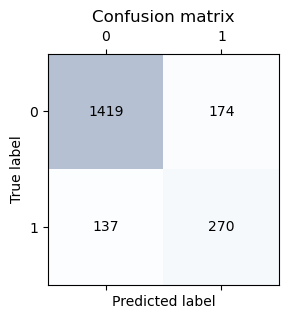

In [20]:
# confusion matrix visualization
fig, ax = plt.subplots(figsize=(3, 3))
ax.matshow(conf_matrix, cmap='Blues', alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix')
plt.show()

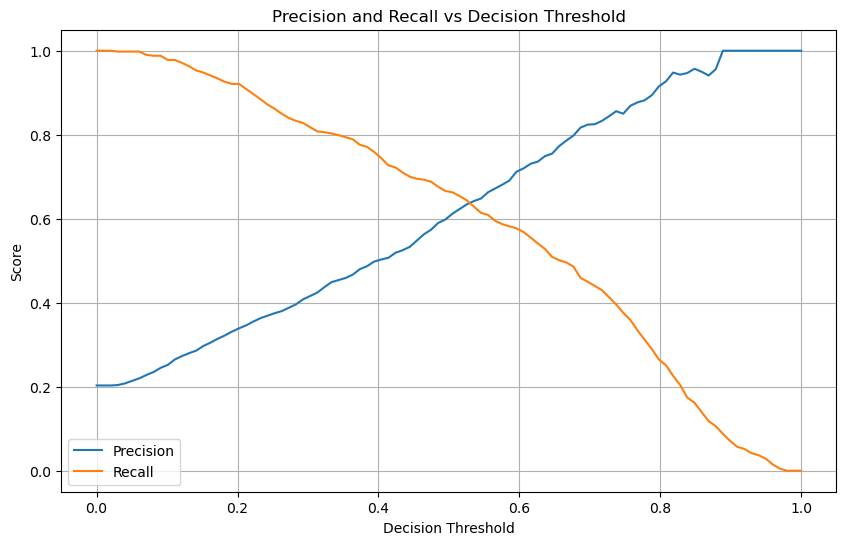

In [21]:
# Precision/Recall as a function of the decision threshold

precisions = []
recalls = []
f1_scores = []
thresholds = np.linspace(0, 1, 100)

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)

    precisions.append(round(precision_score(y_test, y_pred_t, zero_division=1), 3))
    recalls.append(round(recall_score(y_test, y_pred_t, zero_division=0), 3))
    f1_scores.append(round(f1_score(y_test, y_pred_t, zero_division=0), 3))

# data frame for searching decisions thresholds
df_scores_t = pd.DataFrame({
    "threshold": thresholds,
    "f1": f1_scores,
    "precision": precisions,
    "recall": recalls
})

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')

plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Decision Threshold')

plt.grid(True)
plt.legend()

plt.show()

In [22]:
# serch decision threshold for max f1 and f1 max
t_f1_max = df_scores_t.loc[df_scores_t['f1'].idxmax(), 'threshold']
best_f1 = df_scores_t.loc[df_scores_t['f1'].idxmax(), 'f1']

# serch decision threshold for precision bigger then 0.89

mask_p90 = (df_scores_t['precision'] > 0.89)
t_prec_90_row = df_scores_t.loc[
    df_scores_t.loc[mask_p90, 'threshold'].idxmin()]

t_prec_90 = t_prec_90_row['threshold']

print(f'Threshold: {t_f1_max.round(2)},for best F1: {best_f1}')
print(f'Precision = 0.9 , for threshold: {t_prec_90.round(2)}')

Threshold: 0.53,for best F1: 0.639
Precision = 0.9 , for threshold: 0.79


In [23]:
# flag for increased marketing
y_pred_mark_a = (y_proba >= t_prec_90).astype(int)
conf_matrix_90 = confusion_matrix(y_test, y_pred_mark_a)
print(conf_matrix_90)

[[1579   14]
 [ 289  118]]


In [24]:
# flag for normal marketing
y_pred_mark_n = (y_proba >= t_f1_max).astype(int)
conf_matrix_f1 = confusion_matrix(y_test, y_pred_mark_n)
print(conf_matrix_f1)

[[1442  151]
 [ 145  262]]


In [25]:
# the file for the next analysis in LangChain.
df_marketing = pd.DataFrame({
    'increased marketing': y_pred_mark_a,
    'normal marketing': y_pred_mark_n, },
    index=X_test_raw.index,

)
df_final = pd.concat(
    [X_test_raw, df_shap, df_marketing],
    axis=1)
df_final['customer_id'] = id_test.values

In [26]:
df_final.head()


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,...,products_number,active_member,country_France,country_Germany,country_Spain,gender_Female,gender_Male,increased marketing,normal marketing,customer_id
5702,585,France,Male,36,7,0.00,2,1,0,94283.09,...,-1.352275,0.288797,-0.060666,-0.071131,0.004021,-0.187672,-0.108917,0,0,15749540
3667,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,...,-1.120842,0.297739,0.087483,0.305622,-0.005204,-0.127840,-0.071647,0,0,15807340
1617,557,Spain,Female,40,4,0.00,2,0,1,105433.53,...,-1.283193,-0.316716,0.026440,-0.072154,-0.028759,0.198723,0.115173,0,0,15801062
5673,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,...,-0.831618,0.317737,0.074113,-0.079994,0.067191,-0.154636,-0.077411,0,0,15572801
4272,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,...,0.228800,-0.377721,0.102482,-0.104897,-0.010877,0.194896,0.080139,0,0,15600708


In [27]:

df_final.to_csv('bank_c_marketing.csv', index=False)